In [1]:
import sys
python_path = sys.executable
print(python_path)


/usr/bin/python3.8


In [ ]:
import gc
import os
import random
import time
from pathlib import Path
import glob

import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
from sklearn.model_selection import train_test_split

# INFO messages are not printed.
# This must be run before loading other modules.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

BE_MASTER = os.environ.get("BE_MASTER")
if not BE_MASTER:
    raise EnvironmentError("BE_MASTER environment variable must be set to the data root")
FOUNDATION_MODEL_ROOT = os.environ.get("FOUNDATION_MODEL_ROOT")
if not FOUNDATION_MODEL_ROOT:
    raise EnvironmentError(
        "FOUNDATION_MODEL_ROOT environment variable must be set to the REMEDIS foundation "
        "model directory (base model from PhysioNet + local fine-tuned checkpoints)"
    )


In [3]:
import numpy as np
numpy_location = np.__file__
print(numpy_location)
import cv2
import openslide
import pandas as pd

import numpy as np
import cv2
import random


/usr/local/lib/python3.8/dist-packages/numpy/__init__.py


In [4]:
import tensorflow_similarity as tfsim
import tensorflow_similarity.visualization as tfsim_visualization
import tensorflow_similarity.callbacks as tfsim_callbacks
import tensorflow_similarity.augmenters as tfsim_augmenters
import tensorflow_similarity.losses as tfsim_losses
import tensorflow_similarity.architectures as tfsim_architectures
from tensorflow_similarity.augmenters.augmentation_utils.random_apply import (
    random_apply,
)

/usr/local/lib/python3.8/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Your CPU supports instructions that this binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2
For maximum performance, you can install NMSLIB from sources 
pip install --no-binary :all: nmslib


In [5]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_addons as tfa 
from tensorflow.keras.layers import AveragePooling2D, Dense, Flatten

/usr/local/lib/python3.8/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [6]:
print("TensorFlow:", tf.__version__)
print("TensorFlow Similarity", tfsim.__version__)

TensorFlow: 2.12.0
TensorFlow Similarity 0.17.1


In [7]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
        
        



In [8]:
# def img_scaling(img):
#     return tf.keras.applications.imagenet_utils.preprocess_input(img, data_format=None, mode="torch")

@tf.function
def simsiam_augmenter(img, blur=True, area_range=(0.8, 1.0)):
    """SimSiam augmenter.

    The SimSiam augmentations are based on the SimCLR augmentations, but have
    some important differences.
    * The crop area lower bound is 20% instead of 8%.
    * The color jitter and grayscale are applied separately instead of together.
    * The color jitter ranges are much smaller.
    * Blur is not applied for the cifar10 dataset.

    args:
        img: Single image tensor of shape (H, W, C)
        blur: If true, apply blur. Should be disabled for cifar10.
        area_range: The upper and lower bound of the random crop percentage.

    returns:
        A single image tensor of shape (H, W, C) with values between 0.0 and 1.0.
    """
    # random resize and crop. Increase the size before we crop.
    # img = tfsim.augmenters.augmentation_utils.cropping.crop_and_resize(
    #     img, 448, 448, area_range=area_range
    # )
    
    img = tf.image.random_crop(img, (448, 448, 3))
    img = tf.image.resize(img, [224, 224])
#     #create mask
#     img_gray = tf.image.rgb_to_grayscale(img)
#     img_blur = tfa.image.gaussian_filter2d(img_gray, [7, 7], 0)
#     _, mask_tissue = tf.nn.threshold(img_blur, 60, 255)
#     _, mask_ink = tf.nn.threshold(img_blur, 30, 255)
#     mask_foreground = mask_tissue - mask_ink

#     mask_tensor = tf.expand_dims(mask_foreground, axis=-1)
#     mask_tensor = tf.tile(mask_tensor, [1, 1, 3])
#     stacked_image = tf.stack([img, mask_tensor], axis=0)
#     threshold = 0.9
#     max_attempts = 20
#     attempts = 0

#     while attempts < max_attempts:
#         crop_tensor = tf.image.random_crop(stacked_image, [2, 224, 224, 3])
#         img = crop_tensor[0]
#         crop_mask = crop_tensor[1]

#         crop_mask = crop_mask[:, :, 0]
#         crop_mask = tf.clip_by_value(crop_mask, 0, 255)
#         crop_mask_01 = crop_mask / 255.0
#         tissue_percent = tf.reduce_sum(crop_mask_01) / tf.size(crop_mask_01)

#         attempts += 1

#         if tissue_percent > threshold:
#             break
#         elif attempts == max_attempts:
#             threshold -= 0.1
#             attempts = 0


    # stack together
    # test tissue content
    #if fails, repeat the crop
    
    
    
    # img = tf.image.random_crop(img, (224,224,3))
    # img = tf.image.resize(img, [224, 224])

    # The following transforms expect the data to be [0, 1]
    img /= 255.0

    # random color jitter
    def _jitter_transform(x):
        return tfsim.augmenters.augmentation_utils.color_jitter.color_jitter_rand(
            x,
            np.random.uniform(0.0, 0.4),
            np.random.uniform(0.0, 0.4),
            np.random.uniform(0.0, 0.4),
            np.random.uniform(0.0, 0.1),
            "multiplicative",
        )

    img = tfsim.augmenters.augmentation_utils.random_apply.random_apply(_jitter_transform, p=0.8, x=img)

    # # random grayscale
    def _grascayle_transform(x):
        return tfsim.augmenters.augmentation_utils.color_jitter.to_grayscale(x)

    img = tfsim.augmenters.augmentation_utils.random_apply.random_apply(_grascayle_transform, p=0.1, x=img)

    # optional random gaussian blur
    img = tfsim.augmenters.augmentation_utils.blur.random_blur(img, height = 224, width = 224, p=0.5)

    # random horizontal flip
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)

    # scale the data back to [0, 255]
    img = img * 255.0
    img = tf.clip_by_value(img, 0.0, 255.0)

    return img


@tf.function()
def process(img):
    view1 = simsiam_augmenter(img, blur=False)
    view1.set_shape((224, 224, 3))
    view2 = simsiam_augmenter(img, blur=False)
    view2.set_shape((224, 224, 3))
    return (view1, view2)

In [9]:

ALGORITHM = "simclr"
IMG_SIZE = 224
INIT_LR = 1e-3  # Initial LR for the learning rate schedule, see section B.1 in the paper.
TEMPERATURE = 0.5  # Tuned for CIFAR10, see section B.9 in the paper.

BATCH_SIZE = 64
PRE_TRAIN_EPOCHS = 200
VAL_STEPS_PER_EPOCH = 20
WEIGHT_DECAY = 5e-4
DIM = 1024  # The layer size for the projector and predictor models.
WARMUP_LR = 0.0
WARMUP_STEPS = 0

In [ ]:
base_path = os.path.join(BE_MASTER, "0.input/flow/roi/flow/MDA12_ROI_patches_finetuning_250217/")

BATCH_SIZE=256

train_ds =  tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_path, "train"),
    image_size=(1024,1024),
    labels=None,
    batch_size=None,
    shuffle=True,
    seed=123,
    color_mode="rgb"
)
train_ds = train_ds.map(process, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

val_ds =  tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(base_path, "val"),
    image_size=(1024,1024),
    labels=None,
    batch_size=None,
    shuffle=True,
    seed=123,
    color_mode="rgb"
)
val_ds = val_ds.map(process, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


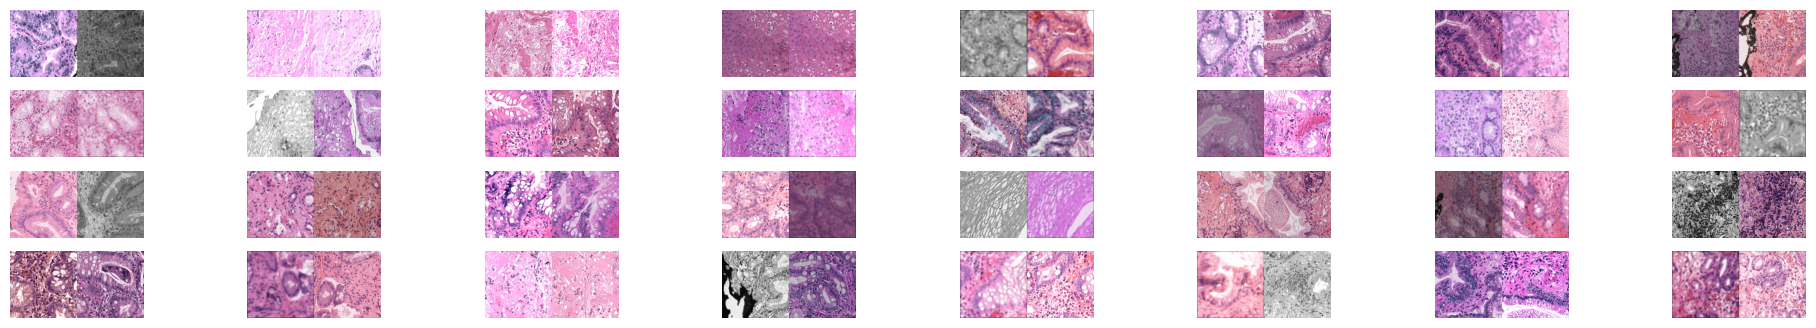

In [11]:
display_imgs = next(train_ds.as_numpy_iterator())
max_pixel = np.max([display_imgs[0].max(), display_imgs[1].max()])
min_pixel = np.min([display_imgs[0].min(), display_imgs[1].min()])

tfsim_visualization.visualize_views(
    views=display_imgs,
    num_imgs=32,
    views_per_col=8,
    max_pixel_value=max_pixel,
    min_pixel_value=min_pixel,
)

In [12]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [13]:
device = '/gpu:0' if tf.config.list_physical_devices('GPU') else '/cpu:0'
print(device)

/gpu:0


In [ ]:
foundation_model_base = os.path.join(FOUNDATION_MODEL_ROOT, "physionet.org/files/medical-ai-research-foundation/1.0.0/")
def foundationModel(arch = 'path-50x1-remedis-s',no_linear=False, noAverage = False, trainable = False):
    device = '/gpu:0' if tf.config.list_physical_devices('GPU') else '/cpu:0'
    # load_options = tf.saved_model.LoadOptions(experimental_io_device='/job:localhost')

    with tf.device(device):
        hub_path = os.path.join(foundation_model_base,arch)

        module_keras=hub.KerasLayer(hub_path, trainable=trainable)

        model = tf.keras.Sequential(module_keras)
        
        # model = tf.keras.Sequential([
        #     tf.keras.layers.InputLayer(input_shape=(224, 224, 3)),
        #     module_keras
        # ])
        
        #model.add(Flatten()) # avrpool
        if not noAverage:
            model.add(AveragePooling2D(pool_size=(7, 7))) #TODO change to trainable conv layer
            model.add(Flatten())
        if not no_linear:
            model.add(Dense(1024, activation= None,use_bias=False)) # input_shape=(131072,)
        model.build(input_shape=(None, 224,224,3))
        # model.build()


    return model
arch = 'path-50x1-remedis-s'
# remedis_model.summary()

In [15]:
projector = None
predictor = None

In [16]:
# strategy = tf.distribute.MirroredStrategy()
# with strategy.scope():

with tf.device('/GPU:0'):  # Use '/GPU:0' for the first GPU, or '/GPU:1' for the second GPU, etc.
    
    remedis_model = foundationModel(arch = arch)
    contrastive_model = tfsim.models.create_contrastive_model(
        backbone=remedis_model,
        projector=projector,
        predictor=predictor,
        algorithm=ALGORITHM,
        name=ALGORITHM,
    )
    
    loss = tfsim_losses.SimCLRLoss(name=ALGORITHM, temperature=TEMPERATURE)
    optimizer = tfa.optimizers.LAMB(learning_rate=INIT_LR)
    contrastive_model.compile(
    optimizer=optimizer,
    loss=loss,
    )


In [17]:
contrastive_model.summary()

[Backbone]
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 7, 7, 2048)        23496256  
                                                                 
 average_pooling2d (AverageP  (None, 1, 1, 2048)       0         
 ooling2D)                                                       
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 1024)              2097152   
                                                                 
Total params: 25,593,408
Trainable params: 2,097,152
Non-trainable params: 23,496,256
_________________________________________________________________

[Projector]
Model: "projector"
___________________________________________________________

In [ ]:
DATA_PATH = Path(FOUNDATION_MODEL_ROOT) / "finetuned" / "448_ds2"


log_dir = DATA_PATH / arch / "models"  / "logs" / f"{loss.name}_{time.time()}"
chkpt_dir = DATA_PATH / arch / "models" / "checkpoints" / f"{loss.name}_{time.time()}"


# evb = tfsim_callbacks.EvalCallback(
#     img_scaling(tf.cast(x_query, tf.float32)),
#     y_query,
#     img_scaling(tf.cast(x_index, tf.float32)),
#     y_index,
#     metrics=["binary_accuracy"],
#     k=1,
#     tb_logdir=log_dir,
# )
tbc = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1,
    update_freq=100,
)
# mcp = tf.keras.callbacks.ModelCheckpoint(
#     filepath=chkpt_dir,
#     monitor="val_loss",
#     mode="min",
#     save_best_only=True,
#     save_weights_only=False,
# )

earlystop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.01,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=30
)


In [19]:
history = contrastive_model.fit(
    train_ds,
    epochs=PRE_TRAIN_EPOCHS,
    # steps_per_epoch=PRE_TRAIN_STEPS_PER_EPOCH,
    validation_data=val_ds,
    # validation_steps=VAL_STEPS_PER_EPOCH,
    callbacks=[tbc, earlystop],
    verbose=1,
)

Epoch 1/200
3/3 [==============================] - 45s 10s/step - loss: 10.9873 - proj_std: 0.0441 - val_loss: 11.4922 - val_proj_std: 0.0197
Epoch 2/200
3/3 [==============================] - 11s 3s/step - loss: 10.8918 - proj_std: 0.0441 - val_loss: 11.3888 - val_proj_std: 0.0212
Epoch 3/200
3/3 [==============================] - 10s 3s/step - loss: 10.7629 - proj_std: 0.0441 - val_loss: 11.3352 - val_proj_std: 0.0228
Epoch 4/200
3/3 [==============================] - 13s 4s/step - loss: 10.6277 - proj_std: 0.0440 - val_loss: 11.2062 - val_proj_std: 0.0242
Epoch 5/200
3/3 [==============================] - 10s 3s/step - loss: 10.5299 - proj_std: 0.0440 - val_loss: 11.0972 - val_proj_std: 0.0258
Epoch 6/200
3/3 [==============================] - 10s 3s/step - loss: 10.4340 - proj_std: 0.0440 - val_loss: 10.9942 - val_proj_std: 0.0274
Epoch 7/200
3/3 [==============================] - 11s 3s/step - loss: 10.4178 - proj_std: 0.0440 - val_loss: 10.8688 - val_proj_std: 0.0287
Epoch 8/200


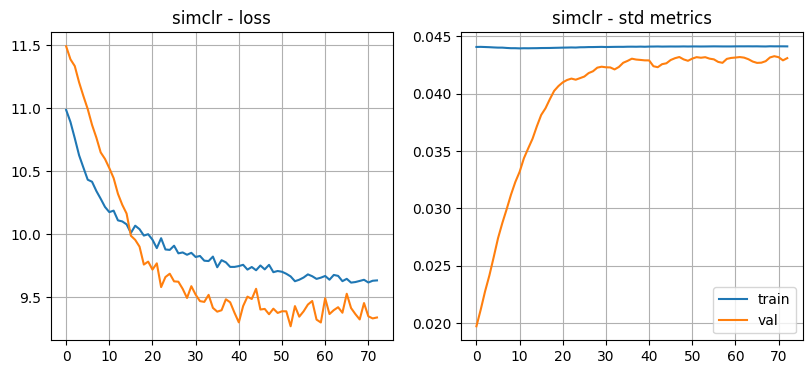

In [20]:
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history['val_loss'], label="val_loss")
plt.grid()
plt.title(f"{loss.name} - loss")

plt.subplot(1, 3, 2)
plt.plot(history.history["proj_std"], label="train")
plt.plot(history.history["val_proj_std"], label="val")
# if "pred_std" in history.history:
    # plt.plot(history.history["pred_std"], label="pred_train")
    
    
plt.grid()
plt.title(f"{loss.name} - std metrics")
plt.legend()

# plt.subplot(1, 3, 3)
# plt.plot(history.history["binary_accuracy"], label="acc")
# plt.grid()
# plt.title(f"{loss.name} - match metrics")
# plt.legend()

plt.show()

In [ ]:
output_base_path = os.path.join(FOUNDATION_MODEL_ROOT, "finetuned/448_ds2/")
output_path = os.path.join(output_base_path, arch, "saved_backbone_model")
tf.saved_model.save(contrastive_model.backbone, output_path)

In [22]:
contrastive_model.summary()

[Backbone]
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer (KerasLayer)    (None, 7, 7, 2048)        23496256  
                                                                 
 average_pooling2d (AverageP  (None, 1, 1, 2048)       0         
 ooling2D)                                                       
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense (Dense)               (None, 1024)              2097152   
                                                                 
Total params: 25,593,408
Trainable params: 2,097,152
Non-trainable params: 23,496,256
_________________________________________________________________

[Projector]
Model: "projector"
___________________________________________________________